# 05. AI Tools Adoption & Sentiments

This notebook details developer AI adoption, sentiment, and tooling popularity from 2023 to 2025. We cover:
1. Sentiment on benefits vs. threats of AI
2. Trust in AI outputs (2025)
3. Top AI Search and Developer tools worked with
4. AI selection and usage patterns across developer roles

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.spatial.distance import cosine
from sklearn.cluster import MiniBatchKMeans
from sentence_transformers import SentenceTransformer

# Set style for visuals
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Resolve path to sql_connector relative to this notebook
current_dir = os.path.abspath('')
project_root = os.path.dirname(current_dir)
silver_utils_dir = os.path.join(project_root, 'Data Warehouse', 'Silver Layer', 'utils')
sys.path.append(silver_utils_dir)

# Ensure the images output directory exists
images_dir = os.path.join(current_dir, 'images')
os.makedirs(images_dir, exist_ok=True)

from sql_connector import SQLConnector

db = SQLConnector("Stack_Overflow_Survey")
db.connect()

Successfully Connected to Stack_Overflow_Survey


### 1. Developer Sentiment on AI Benefits (2024)

Let's see if developer sentiments about the benefits of AI tools have become more optimistic or cautious.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


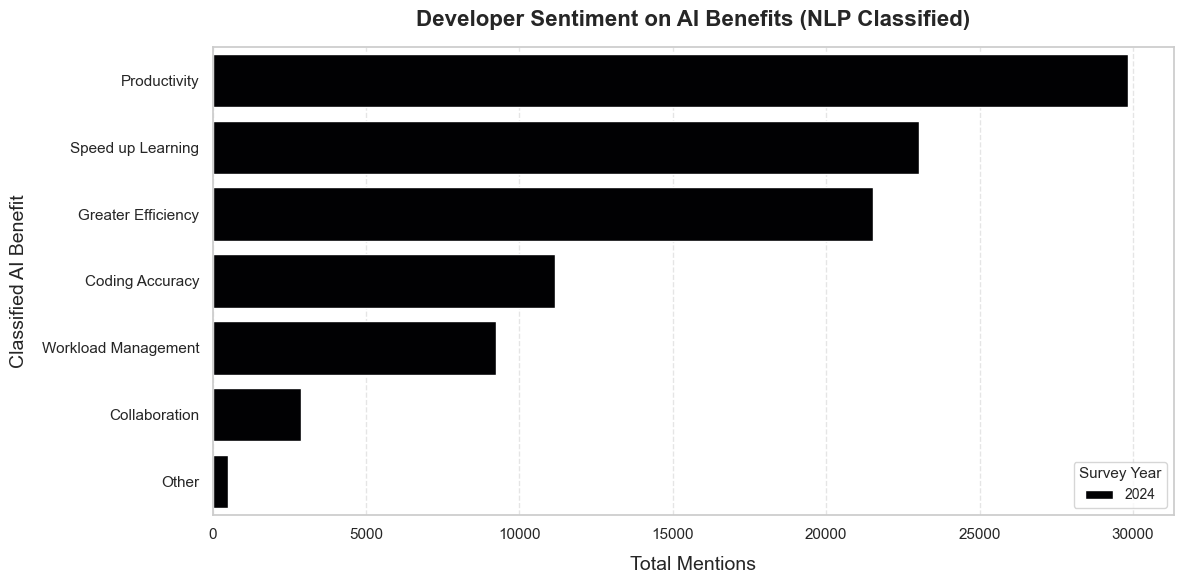

In [44]:
ai_query = """
SELECT 
    YEAR(SurveyYear) AS Year,
    AIBen AS AI_Benefit_Sentiment,
    COUNT(*) AS Count
FROM Gold.Fact_Survey
WHERE AIBen IS NOT NULL AND AIBen <> '' AND AIBen <> 'Unknown' and YEAR(SurveyYear)=2024
GROUP BY YEAR(SurveyYear), AIBen;
"""

df_ai = db.read_query(ai_query)

if df_ai is not None and not df_ai.empty:
    df_chart = df_ai.copy()
    
    labels = [
        'Greater efficiency',
        'Speed up learning',
        'Improve accuracy in coding',
        'Make workload more manageable',
        'Increase productivity',
        'Improve collaboration'
    ]
    
    unique_responses = df_chart['AI_Benefit_Sentiment'].unique()
    corpus = list(unique_responses) + labels
    
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(corpus).toarray()
    
    response_vectors = tfidf_matrix[:len(unique_responses)]
    label_vectors = tfidf_matrix[len(unique_responses):]
    
    mapping_dict = {}
    for i, res_vec in enumerate(response_vectors):
        matched_labels = []
        for j, lbl_vec in enumerate(label_vectors):
            score = 1 - cosine(res_vec, lbl_vec)
            if score > 0.3:  
                matched_labels.append(labels[j])
        mapping_dict[unique_responses[i]] = matched_labels if matched_labels else ['Other']

    df_chart['Classified_Labels'] = df_chart['AI_Benefit_Sentiment'].map(mapping_dict)
    df_exploded = df_chart.explode('Classified_Labels')
    
    short_label_mapping = {
        'Greater efficiency': 'Greater Efficiency',
        'Speed up learning': 'Speed up Learning',
        'Improve accuracy in coding': 'Coding Accuracy',
        'Make workload more manageable': 'Workload Management',
        'Increase productivity': 'Productivity',
        'Improve collaboration': 'Collaboration',
        'Other': 'Other'
    }
    df_exploded['Classified_Labels'] = df_exploded['Classified_Labels'].map(short_label_mapping)
    
    df_exploded['Total_Count'] = df_exploded['Count']
    df_grouped = df_exploded.groupby(['Year', 'Classified_Labels'])['Total_Count'].sum().reset_index()
    df_grouped = df_grouped.sort_values(by='Total_Count', ascending=False)

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        data=df_grouped, 
        x='Total_Count', 
        y='Classified_Labels', 
        hue='Year', 
        palette='magma'
    )
    
    plt.title('Developer Sentiment on AI Benefits (NLP Classified)', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Total Mentions', fontsize=14, labelpad=10)
    plt.ylabel('Classified AI Benefit', fontsize=14, labelpad=10)

    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    plt.legend(title='Survey Year', title_fontsize=11, fontsize=10)
    
    plt.tight_layout()
    plt.show()
else:
    print("No data available.")


### 2. Developer Trust in AI Outputs (2025)

How much do developers trust AI tool outputs?

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


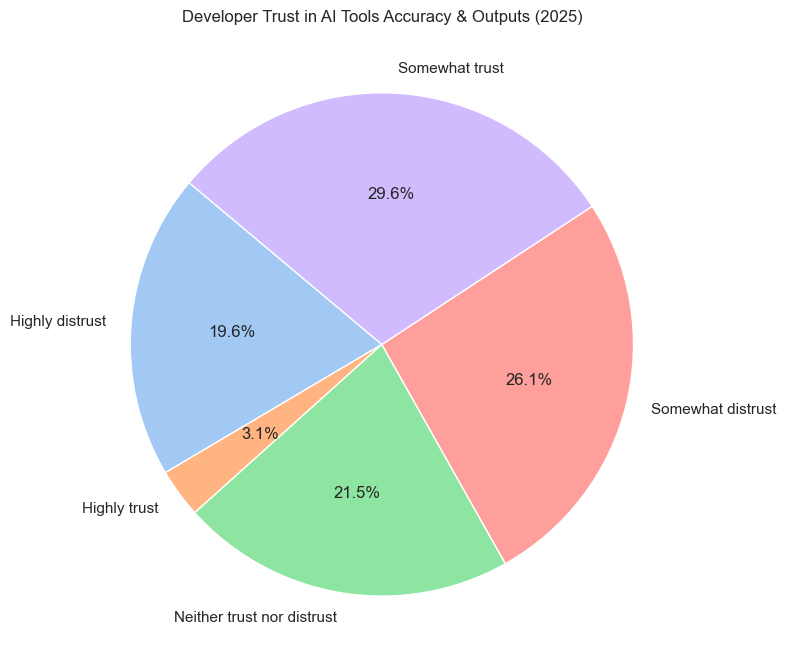

In [3]:
trust_query = """
SELECT 
    o.AIAcc AS AI_Trust,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_AICentral c ON f.Dim_AICentralID = c.Dim_AICentralID
JOIN Snowflake.Dim_AIOpinions o ON c.Dim_AIOpinionsID = o.Dim_AIOpinionsID
WHERE YEAR(f.SurveyYear) = 2025 
  AND o.AIAcc IS NOT NULL AND o.AIAcc <> '' AND o.AIAcc <> 'Unknown'
GROUP BY o.AIAcc;
"""
df_trust = db.read_query(trust_query)

if df_trust is not None and not df_trust.empty:
    plt.figure(figsize=(8, 8))
    colors = sns.color_palette('pastel')[0:5]
    plt.pie(df_trust['Count'], labels=df_trust['AI_Trust'], autopct='%1.1f%%', colors=colors, startangle=140)
    plt.title('Developer Trust in AI Tools Accuracy & Outputs (2025)')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '05_ai_trust.png'), dpi=300)
    plt.show()
else:
    print("No AI trust data available.")

### 3. Popular AI Search vs. AI Developer Tools (2025)

Let's see which AI tools are the most popular.

Query executed successfully
Query executed successfully


C:\Users\Ayush\AppData\Local\Temp\ipykernel_19624\469460363.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_worked, x='Count', y='AIModel', palette='viridis')


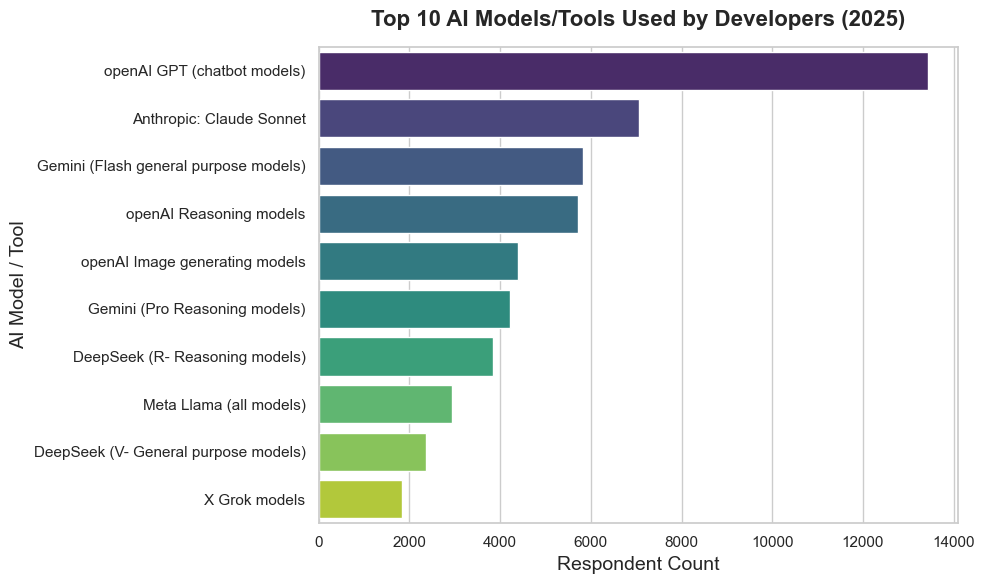

C:\Users\Ayush\AppData\Local\Temp\ipykernel_19624\469460363.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_want, x='Count', y='AIModel', palette='magma')


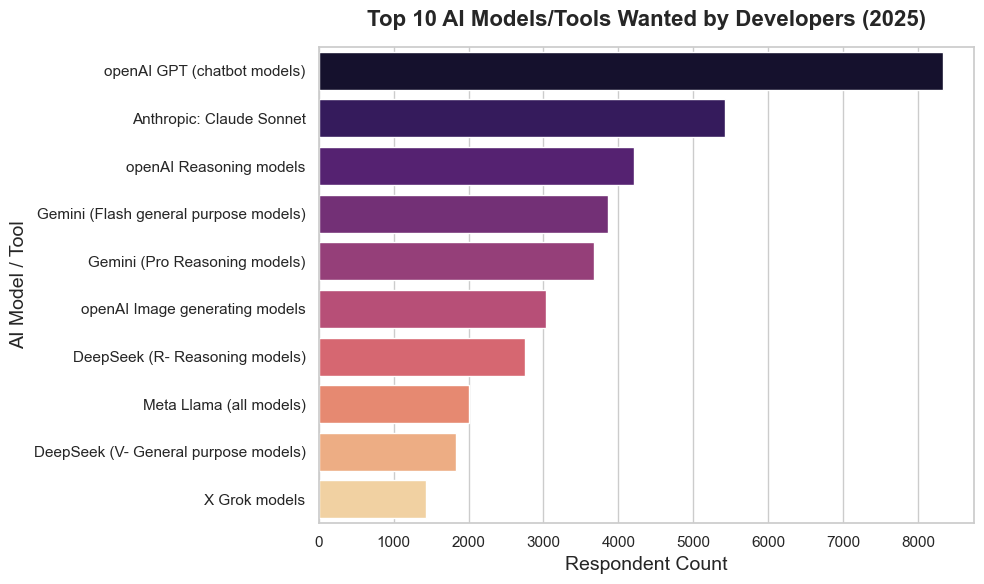

In [26]:
#  Query for AI Models Worked With (2025)
worked_with_query = """
SELECT 
    b.AIModelsHaveWorkedWith_Clean AS AIModel,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Bridge_AIModelsHaveWorkedWith_Clean b ON f.ResponseKey = b.ResponseKey
WHERE YEAR(f.SurveyYear) = 2025
  AND b.AIModelsHaveWorkedWith_Clean IS NOT NULL 
  AND b.AIModelsHaveWorkedWith_Clean <> 'Other/Unknown' 
  AND b.AIModelsHaveWorkedWith_Clean <> 'NA'          
  AND b.AIModelsHaveWorkedWith_Clean <> ''
GROUP BY b.AIModelsHaveWorkedWith_Clean;
"""

#  Query for AI Models Wanted (2025)
want_to_work_query = """
SELECT 
    b.AIModelsWantToWorkWith_Clean AS AIModel,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Bridge_AIModelsWantToWorkWith_Clean b ON f.ResponseKey = b.ResponseKey
WHERE YEAR(f.SurveyYear) = 2025
  AND b.AIModelsWantToWorkWith_Clean IS NOT NULL 
  AND b.AIModelsWantToWorkWith_Clean <> 'Other/Unknown' 
  AND b.AIModelsWantToWorkWith_Clean <> 'NA'          
  AND b.AIModelsWantToWorkWith_Clean <> ''
GROUP BY b.AIModelsWantToWorkWith_Clean;
"""


df_worked = db.read_query(worked_with_query)
df_want = db.read_query(want_to_work_query)

# Plot 1: AI Models Worked With
if df_worked is not None and not df_worked.empty:
    df_worked = df_worked.sort_values(by='Count', ascending=False).head(10)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_worked, x='Count', y='AIModel', palette='viridis')
    plt.title('Top 10 AI Models/Tools Used by Developers (2025)', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Respondent Count', fontsize=14)
    plt.ylabel('AI Model / Tool', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No 2025 data available for AI Models Worked With.")

# Plot 2: AI Models Wanted
if df_want is not None and not df_want.empty:
    df_want = df_want.sort_values(by='Count', ascending=False).head(10)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_want, x='Count', y='AIModel', palette='magma')
    plt.title('Top 10 AI Models/Tools Wanted by Developers (2025)', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Respondent Count', fontsize=14)
    plt.ylabel('AI Model / Tool', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No 2025 data available for AI Models Wanted.")


### 4. AI Adoption Status by Key Developer Roles (2025)

Let's see if Data Scientists or Sysadmins are adopting AI tools faster.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


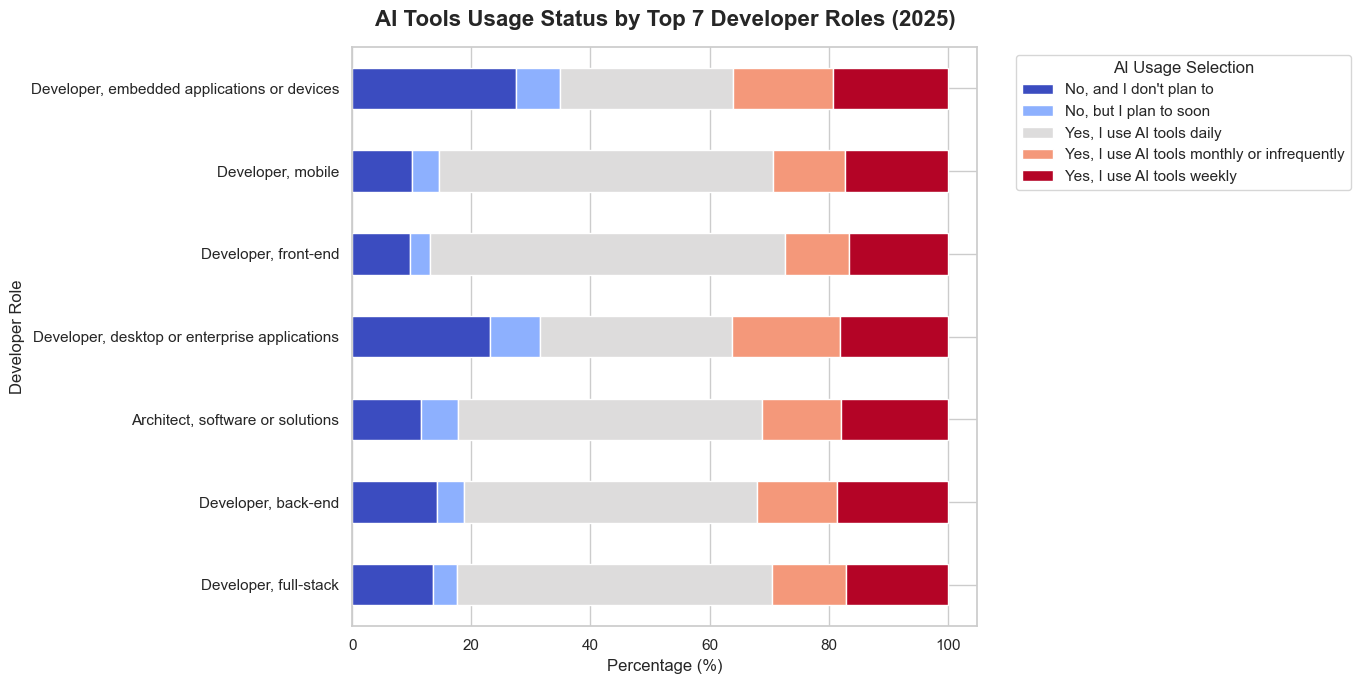

In [46]:
role_ai_query = """
SELECT 
    role.DevType_Clean AS DevRole,
    o.AISelect AS AI_Usage_Select,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Bridge_DevType_Clean role ON f.ResponseKey = role.ResponseKey
JOIN Snowflake.Dim_AICentral c ON f.Dim_AICentralID = c.Dim_AICentralID
JOIN Snowflake.Dim_AIOpinions o ON c.Dim_AIOpinionsID = o.Dim_AIOpinionsID
WHERE YEAR(f.SurveyYear) = 2025
  AND o.AISelect IS NOT NULL AND o.AISelect <> 'Unknown' AND o.AISelect <> ''
  AND role.DevType_Clean NOT IN ('Other (please specify):', 'Student')
GROUP BY role.DevType_Clean, o.AISelect;
"""
df_role_ai = db.read_query(role_ai_query)

if df_role_ai is not None and not df_role_ai.empty:
    top_7_roles = df_role_ai.groupby('DevRole')['Count'].sum().nlargest(7).index
    df_role_ai_filtered = df_role_ai[df_role_ai['DevRole'].isin(top_7_roles)].copy()
    
    df_role_pivot = df_role_ai_filtered.pivot(index='DevRole', columns='AI_Usage_Select', values='Count').fillna(0)
    df_role_pivot = df_role_pivot.loc[top_7_roles]
    
    df_role_pct = df_role_pivot.div(df_role_pivot.sum(axis=1), axis=0) * 100
    
    df_role_pct.plot(kind='barh', stacked=True, figsize=(14, 7), colormap='coolwarm')
    plt.title('AI Tools Usage Status by Top 7 Developer Roles (2025)', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Percentage (%)', fontsize=12)
    plt.ylabel('Developer Role', fontsize=12)
    plt.legend(title='AI Usage Selection', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '05_ai_adoption_by_role.png'), dpi=300)
    plt.show()
else:
    print("No role/AI data available.")


In [6]:
db.close()

Connection closed.
